In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn import mixture
from sklearn.cluster import DBSCAN
from copy import copy

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

from src import render
from src import localise as _localise
from src import postprocess as _postprocess

from jupyter_bbox_widget import BBoxWidget
import ipywidgets as widgets
from io import BytesIO
from PIL import Image
import HelperFunctions

from src import FiducialDetection

FD = FiducialDetection.FiducialDetector()


import types

import DriftCorrectionFunctions as DCF
from src.LinkingFunctions import link_localisations


H_F = HelperFunctions.Helper_Functions()

INFO:Constants:Logging to file: /home/jsb92/Documents/pyBayerSMLM/logs/Constants_20260405_124508.log
/tmp/ipykernel_1980677/535978356.py:29: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [2]:
data_folder = "../../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [4]:
image_folder = "/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/AlphaSynPAINT/20260205_alpha_syn_NR_PLL/1nM_NR_10uM_asyn72h_2p5AuNP/50ms_70p_515_LP515_bp650_200_4"
image_files = H_F.file_search(image_folder, ".tif", "")

In [5]:
localisation_files = H_F.file_search(image_folder, ".h5", "")
metadata_files = H_F.file_search(image_folder, "metadata", "")
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [ ]:
loc_data = pd.read_hdf(localisation_files[0])

In [ ]:
plt.plot(loc_data.groupby('frame').count()['xc'])

In [ ]:
plt.hist(loc_data['chi_sqr'], 100);
plt.yscale('log')
plt.show()

In [ ]:
loc_data = loc_data[loc_data["xc_err"] < 100/69]
loc_data = loc_data[loc_data["yc_err"] < 100/69]

loc_data = loc_data[loc_data["xc_err"] > 0]
loc_data = loc_data[loc_data["yc_err"] > 0]

loc_data = loc_data[loc_data["s_x_err"] < 100/69]
loc_data = loc_data[loc_data["s_y_err"] < 100/69]

loc_data = loc_data[(loc_data["s_x"] > 75/69) & (loc_data["s_x"] < 175/69)]
loc_data = loc_data[(loc_data["s_y"] > 75/69) & (loc_data["s_y"] < 175/69)]

loc_data = loc_data[loc_data["A_B_err"] < 0.01]
loc_data = loc_data[loc_data["A_G_err"] < 0.01]
loc_data = loc_data[loc_data["A_R_err"] < 0.01]

loc_data = loc_data[loc_data["A_B"] > 0.005]
loc_data = loc_data[loc_data["A_G"] > 0.05]
loc_data = loc_data[loc_data["A_R"] > 0.05]

loc_data = loc_data[loc_data["bg_B_err"] < 0.15]
loc_data = loc_data[loc_data["bg_G_err"] < 0.15]
loc_data = loc_data[loc_data["bg_R_err"] < 0.15]

#loc_data = loc_data[~((loc_data['spot_snr'] < 2) & (loc_data['photons'] < 500) & (loc_data['spot_matched_filter_response'] < 100))]


#loc_data = loc_data[loc_data["photons"] < 100000]
loc_data = loc_data[loc_data["photons"] > 200]


loc_data = loc_data[loc_data["chi_sqr"] < 4]

In [ ]:
len(loc_data)

In [ ]:
plt.hist(loc_data['A_R'], 1000, color='red');
plt.hist(loc_data['A_G'], 1000, alpha=0.5, color='darkgreen');
#plt.hist(loc_data['A_B'], 1000, alpha=0.5, color='lightblue');
plt.xlim([0, 1])
plt.show()

In [ ]:
drift_corrector = DCF.Drift_Correction_Functions()

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

corrected_locs, drift_result = drift_corrector.undrift(locs=loc_data.to_records(index=False),
                                          info=info,
                                          method="aim",
                                          segmentation=10,
                                            intersect_d=20/69,
                                          roi_r=60/69,
                                         )
corrected_locs = pd.DataFrame(corrected_locs)
plt.plot(drift_result.drift_x*69)
plt.plot(drift_result.drift_y*69)

plt.show()

In [ ]:
link_r = 0.5 * (np.median(corrected_locs['xc_err']) + np.median(corrected_locs['yc_err']))
linked = link_localisations(corrected_locs, n_frames=n_frames, r_max=link_r, max_dark_time=2)

In [ ]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image = render.render(
            locs=linked.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image, cmap='hot', vmax=np.percentile(image, 99.9), cbar='off')

In [ ]:
region_centers, binary_mask, threshold, metadata = drift_corrector.detect_high_density_regions_from_image(
      smoothed_image=image,
      histogram_bins=821,
      threshold_percentile=99.94,
      pixelsize=69.0,
      title="Fiducial Detection"
  )

In [ ]:
info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(linked['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

selected_puncta, selection_metadata = drift_corrector.select_puncta_from_regions(
        locs=linked.to_records(index=False),                             # Your localization data
        region_centres=region_centers,         # Output from Step 1
        binary_mask=binary_mask,               # Output from Step 1
        pixelsize=info[0]['Pixelsize'],
        selection_box_size_nm=500.0,         # Box size around each region center (adjust as needed)
        min_localisations_per_region=int(0.075*info[0]['Frames']),      # Minimum locs for valid fiducial (adjust as needed)
        title="Step 2: Puncta Selection",
        create_plot=True
    )

In [ ]:
linked_fremoved = FD.remove_puncta_locs(linked.to_records(index=False), selected_puncta)
linked_fremoved = pd.DataFrame(linked_fremoved)

In [ ]:
IO._write_h5_database(df=linked_fremoved, filepath=localisation_files[0].split('.h5')[0]+'_Undrifted_Linked_FiducialsRemoved.h5', normalise_photons=False)

In [ ]:
linked_fremoved.columns

In [ ]:
linked_fremoved = pd.read_hdf(localisation_files[-1])

In [ ]:
# Define parameters
MIN_AREA_NM2 = 5000.0  # Minimum area threshold in nm² (50000 nm² = 0.05 µm²)
MIN_LOCS = 50      # Minimum localisations per cluster
PIXEL_SIZE_NM = 69.0  # Camera pixel size in nanometers
OVERSAMPLING = 8      # Super-resolution rendering oversampling


file = localisation_files[-1]
# Run memory-efficient segmentation
# This uses image thresholding instead of DBSCAN - MUCH more memory efficient!
cluster_locs, per_cluster_stats = _postprocess.segment_locs_by_rendered_image(
    linked_fremoved,
    width=width,
    height=height,
    oversampling=OVERSAMPLING,
    pixel_size_nm=PIXEL_SIZE_NM,
    min_area_nm2=MIN_AREA_NM2,
    min_localisations=MIN_LOCS,
    threshold_method='percentile',  # Li thresholding works well for bacterial imaging
    callback='console',
    blur_method='gaussian',
    verbose=True,
)

# Rename columns to match expected output format
cluster_locs = cluster_locs.rename(
    columns={'aggregate_id': 'cluster_id', 'aggregate_area_nm2': 'cluster_area_nm2'}
)
per_cluster_stats = per_cluster_stats.rename(
    columns={'aggregate_id': 'cluster_id'}
)

# Save results (same file names as before)
IO._write_h5_database(
    df=cluster_locs,
    filepath=file.split('.h5')[0] + '_clusteredlocs.h5',
    append=False,
    normalise_photons=False
)

IO._write_h5_database(
    df=per_cluster_stats,
    filepath=file.split('.h5')[0] + '_averagedoverclusters.h5',
    append=False,
    normalise_photons=False
)

In [ ]:
oversampling = 8

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(cluster_locs['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image = render.render(
            locs=cluster_locs.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image, cmap='hot', vmax=np.percentile(image, 99.9), cbar='off')

In [ ]:
plt.hist(cluster_locs['A_R'], 100);
plt.show()

In [ ]:
aggregate_loc_files = H_F.file_search(image_folder, "_aggregatelocs.h5", "")
aggregate_averaged_loc_files = H_F.file_search(image_folder, "_averagedoveraggregates.h5", "")
metadata_files = H_F.file_search(image_folder, "metadata", "")
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [ ]:
import NileRedFunctions
import SpectralFunctions

# Initialize
nrf = NileRedFunctions.NileRed_Functions()

# Define optical setup
filters = [
  "semrock-ff01-650-200",
  "semrock-di03-r514-t1-25x36",
  "semrock-ff01-515-lp",
]

# Setup camera parameters
sf = SpectralFunctions.Spectral_Funcs()
R, G, B, wavelength = sf.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

camera_params = {
  'pixel_QYs': pixel_QYs,
  'wavelength': wavelength,
}

analysis_files = H_F.file_search(image_folder, "Localisations_Undrifted_Linked_FiducialsRemoved_clusteredlocs.h5", "")

MIN_LOCS_ANALYSIS = 10      # Minimum localisations per wl fit

for file in analysis_files:
    # Fit wavelengths from HDF5 file
    # should now average and use average as initial guess
    df_with_wavelengths, grid_info = nrf.fit_wavelengths_pixelated(
      h5_path=file,
      filter_names=filters,
      camera_parameters=camera_params,
      output_path=file,
      min_localisations=MIN_LOCS_ANALYSIS,
      pixel_size_nm=50,
      aggregate_id_column='cluster_id',
    )

In [6]:
analysis_files = H_F.file_search(image_folder, "Localisations_Undrifted_Linked_FiducialsRemoved_clusteredlocs.h5", "")


In [7]:
df_with_wavelengths = pd.read_hdf(analysis_files[0])

In [8]:
averaged = df_with_wavelengths.groupby('pixel_ix', as_index=False).agg(                                                                                                                                                                                                         
      xc       = ('xc',      'mean'),                                                                                                                                                                                                                          
      yc       = ('yc',      'mean'),                                                                                                                                                                                                                            
      A_R      = ('A_R',     'mean'),                                                                                                                                                                                                                            
      A_G      = ('A_G',     'mean'),                                                                                                                                                                                                                            
      A_B      = ('A_B',     'mean'),                                                                                                                                                                                                                            
      photons  = ('photons', 'sum'),  
      wl_pixel = ('wl_pixel', 'mean'),
      n_locs   = ('frame',   'count'),   # number of localisations per pixel                                                                                                                                                                                     
  )
averaged['log_photons'] = np.log10(averaged['photons'])


In [ ]:
import seaborn as sns

fig, axs = plotter.one_column_plot(npanels=2, ratios=[1,1])

axs[0] = plotter.histogram_plot(axs[0], averaged['wl_pixel'], bins=np.histogram_bin_edges(averaged['wl_pixel'], 'fd'),
                               xaxislabel='')
mean=np.mean(averaged['wl_pixel'])
axs[0].vlines(x=mean, ymin=0, ymax=0.12, ls='--', color='red', label=r'$\mu$')

std=np.std(averaged['wl_pixel'])
axs[0].axvspan(mean - std, mean + std, alpha=0.15, color='red', label=r'$\sigma$')

axs[0].set_ylabel(r'probability $\rho$')
axs[0].set_xticklabels([])
axs[0].legend(fontsize=6)
axs[1].grid(True, lw=0.5, alpha=0.5, ls='--', color='grey')

sns.kdeplot(data=averaged, x="wl_pixel", y="log_photons", ax=axs[1], fill=True)
axs[1].set_xlabel('mean wavelength/nm')
axs[1].set_ylabel('log(photons)')
axs[1].set_ylim([3.5, 7])
axs[1].set_yticks([4, 5, 6, 7])
axs[0].set_xlim([590, 650])
axs[1].set_xlim([590, 650])
axs[0].set_ylim([0, 0.07])

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "AlphaSyn_Analysis_Wavelength.svg"), dpi=600, format="svg")
plt.show()

In [11]:
10*0.069

8.625

In [14]:
oversampling=8

n_locs, image_FOV, image_FOV_colour = render.render(
    locs=df_with_wavelengths.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (np.max(df_with_wavelengths['yc']), np.max(df_with_wavelengths['xc']))),
    blur_method="gaussian_colour",
    cparam='wl_pixel',
    c_min=600,
    c_max=645,
    maxdensperc=99.5,
    mindensperc=1,
    min_blur_width=5*0.069
)

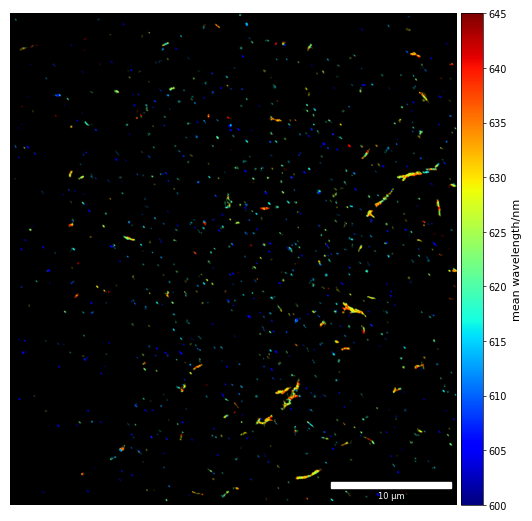

In [15]:
fig, axs = plotter.two_column_plot(height=5, width=5)

axs = plotter.colour_image_plot(axs, image_FOV_colour, cbar="on", cbarlabel=r'mean wavelength/nm', cmap="jet",
                            c_min=600,
                            c_max=645,
                            pixelsize=69/oversampling)



#folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
#plt.savefig(os.path.join(folder, "Image_AlphaSyn_Wavelength.svg"), dpi=600, format="svg")
plt.show()

In [16]:
from scipy.spatial import ConvexHull


def _convex_hull_area_nm2(xc_nm, yc_nm):
    """Convex hull area in nm² from localisation positions.

    Uses scipy.spatial.ConvexHull.  In 2D, hull.volume is the enclosed area
    (hull.area is the perimeter — scipy naming is inherited from the nD case).

    Returns NaN for n < 3 points or degenerate (collinear) clusters.

    Note: this is a lower bound on the true structure area because it ignores
    the localisation-error blur on each point.  Use area_ellipse_nm2 for a
    precision-aware estimate.
    """
    if len(xc_nm) < 3:
        return np.nan
    pts = np.column_stack([xc_nm, yc_nm])
    try:
        hull = ConvexHull(pts)
        return float(hull.volume)   # hull.volume = enclosed area in 2D
    except Exception:
        # QhullError: points are collinear / degenerate
        return np.nan


def compute_aggregate_ellipticity(df_with_wavelengths, pixel_size_nm=69.0,
                                   min_locs_for_shape=10):
    """
    Compute per-aggregate statistics from the point-cloud localisation data,
    correcting shape and area metrics for localisation error.

    WHY CORRECTION MATTERS
    ----------------------
    Each localisation is not a point — it is a 2D Gaussian with width
    (xc_err, yc_err).  Raw covariance eigenvalues therefore include both the
    true structural spread AND the mean localisation error:

        Σ_measured = Σ_structural + diag(⟨σ_x²⟩, ⟨σ_y²⟩)

    Subtracting the mean localisation variance from the diagonal gives
    Σ_structural.  If a corrected eigenvalue is ≤ 0 the aggregate is
    *unresolved* (its extent is smaller than the localisation precision).

    The raw convex hull ignores this blur and underestimates area for sparse
    clusters.  The corrected ellipse area (π × a_corr × b_corr, where
    a_corr/b_corr are the 2σ semi-axes of Σ_structural) gives the footprint
    of the underlying structure assuming a Gaussian density profile.

    AREA COLUMNS
    ------------
    area_nm2        : original DBSCAN-derived area (retained for reference)
    area_hull_nm2   : convex hull of raw localisation positions (lower bound;
                      independent of DBSCAN epsilon; NaN for n < 3 / collinear)
    area_ellipse_nm2: π × major_corr × minor_corr  (precision-corrected ellipse
                      area; NaN when cluster is unresolved in both axes)

    SHAPE COLUMNS  (all from Σ_structural, only for n_locs >= min_locs_for_shape)
    -------------
    eccentricity    : sqrt(1 − λ_min/λ_max),  0 = circular → 1 = rod-like
    aspect_ratio    : major_corr / minor_corr  (better dynamic range for fibrils;
                      e.g. 10:1 fibril → aspect=10 but ecc=0.995)
    major_axis_nm   : 2√λ_max_corr  (2σ of long axis after error subtraction)
    minor_axis_nm   : 2√λ_min_corr  (2σ of short axis; 0 if unresolved)
    unresolved      : True if both corrected eigenvalues are ≤ 0

    WAVELENGTH COLUMNS
    ------------------
    mean_wl, std_wl : photon-weighted mean and std of wl_pixel
                      (weight = A_R + A_G + A_B per localisation)

    Args:
        df_with_wavelengths: DataFrame with columns xc, yc, xc_err, yc_err
            (camera pixels), cluster_id, cluster_area_nm2, wl_pixel, A_R, A_G, A_B.
        pixel_size_nm: Camera pixel size in nm (default 69).
        min_locs_for_shape: Minimum n_locs required to compute shape metrics.

    Returns:
        pd.DataFrame with one row per cluster_id.
    """
    records = []
    for cid, grp in df_with_wavelengths.groupby('cluster_id'):
        xc_nm = grp['xc'].values * pixel_size_nm
        yc_nm = grp['yc'].values * pixel_size_nm
        n = len(grp)

        # ── Convex hull area (raw, lower bound) ───────────────────────────────
        area_hull = _convex_hull_area_nm2(xc_nm, yc_nm)

        # ── Photon-weighted wavelength statistics ─────────────────────────────
        total_phot = grp['A_R'].values + grp['A_G'].values + grp['A_B'].values
        w_sum = total_phot.sum()
        w = total_phot / w_sum if w_sum > 0 else np.ones(n) / n
        wl = grp['wl_pixel'].values
        mean_wl = float(np.sum(w * wl))
        std_wl  = float(np.sqrt(np.sum(w * (wl - mean_wl) ** 2)))

        # ── Precision-corrected covariance and shape ──────────────────────────
        if n >= min_locs_for_shape:
            cov_raw = np.cov(xc_nm, yc_nm)

            # Mean localisation error variance (nm²) — bias to subtract
            # xc_err / yc_err are in camera pixels, convert to nm
            mean_var_x = float(np.mean(grp['xc_err'].values ** 2)) * pixel_size_nm ** 2
            mean_var_y = float(np.mean(grp['yc_err'].values ** 2)) * pixel_size_nm ** 2

            # Structural covariance: clamp diagonal to 0 to avoid negative variances
            cov_corr = cov_raw.copy()
            cov_corr[0, 0] = max(cov_raw[0, 0] - mean_var_x, 0.0)
            cov_corr[1, 1] = max(cov_raw[1, 1] - mean_var_y, 0.0)

            eigvals = np.linalg.eigvalsh(cov_corr)  # ascending order
            lam_max = max(float(eigvals[-1]), 0.0)
            lam_min = max(float(eigvals[0]),  0.0)

            unresolved = (lam_max == 0.0)

            if not unresolved:
                major  = 2.0 * np.sqrt(lam_max)
                minor  = 2.0 * np.sqrt(lam_min)
                ecc    = float(np.sqrt(max(0.0, 1.0 - lam_min / lam_max)))
                aspect = (major / minor) if minor > 1e-6 else np.nan
                # Ellipse area: π × a × b where a,b are 2σ semi-axes
                area_ellipse = float(np.pi * major * minor)
            else:
                major = minor = ecc = aspect = area_ellipse = np.nan
        else:
            ecc = major = minor = aspect = area_ellipse = np.nan
            unresolved = np.nan

        records.append({
            'cluster_id':       cid,
            'area_nm2':         grp['cluster_area_nm2'].iloc[0],
            'area_hull_nm2':    area_hull,
            'area_ellipse_nm2': area_ellipse,
            'mean_wl':          mean_wl,
            'std_wl':           std_wl,
            'n_locs':           n,
            'eccentricity':     ecc,
            'aspect_ratio':     aspect,
            'major_axis_nm':    major,
            'minor_axis_nm':    minor,
            'unresolved':       unresolved,
            'cx_px':            float(grp['xc'].mean()),
            'cy_px':            float(grp['yc'].mean()),
        })
    return pd.DataFrame(records)

In [19]:
# Build per-aggregate stats table.
# All shape metrics use the precision-CORRECTED covariance:
#   Σ_structural = Σ_measured − diag(⟨σ_x²⟩, ⟨σ_y²⟩)
# so major/minor axes, eccentricity and aspect_ratio reflect the true
# structural spread, not the localisation error.
#
# Three area estimates are available:
#   area_nm2        — area of the thresholded rendered image region from
#                     segment_locs_by_rendered_image (depends on oversampling,
#                     blur and threshold percentile; not a direct measurement)
#   area_hull_nm2   — convex hull of the raw localisation positions
#                     (parameter-free; lower bound on true area)
#   area_ellipse_nm2 — π × major_corr × minor_corr from the precision-corrected
#                     covariance ellipse (physically meaningful; NaN if unresolved)
#
# unresolved=True means the aggregate extent is below the localisation precision.
agg_stats = compute_aggregate_ellipticity(df_with_wavelengths, pixel_size_nm=69.0,
                                           min_locs_for_shape=10)

print(f"Total aggregates: {len(agg_stats)}")
print(f"  with shape info (n_locs >= 10): {agg_stats['eccentricity'].notna().sum()}")
print(f"  too small for shape (n_locs < 10): {agg_stats['eccentricity'].isna().sum()}")
print(f"  unresolved (extent < loc. precision): {(agg_stats['unresolved'] == True).sum()}")

agg_stats.sort_values('aspect_ratio', ascending=False)[
    ['cluster_id', 'area_ellipse_nm2', 'area_hull_nm2', 'mean_wl', 'std_wl',
     'eccentricity', 'aspect_ratio', 'major_axis_nm', 'minor_axis_nm',
     'unresolved', 'n_locs']
].round(1).head(30)

Total aggregates: 904
  with shape info (n_locs >= 10): 904
  too small for shape (n_locs < 10): 0
  unresolved (extent < loc. precision): 0


,cluster_id,area_ellipse_nm2,area_hull_nm2,mean_wl,std_wl,eccentricity,aspect_ratio,major_axis_nm,minor_axis_nm,unresolved,n_locs
369,369,2681.7,14287.7,636.9,0.0,1.0,27.0,152.0,5.6,False,61
296,296,1291.0,17700.4,607.0,2.8,1.0,27.0,105.3,3.9,False,102
364,364,2553.6,16749.0,614.7,3.3,1.0,26.9,147.9,5.5,False,63
353,353,1807.9,10748.0,627.9,1.3,1.0,22.0,112.5,5.1,False,54
294,294,2762.0,21082.8,630.7,0.0,1.0,20.6,134.7,6.5,False,54
331,331,2055.1,12812.1,614.7,0.0,1.0,19.7,113.5,5.8,False,54
112,112,24753.4,75429.4,618.5,5.9,1.0,19.3,389.6,20.2,False,425
270,270,9615.6,24634.1,616.1,1.8,1.0,18.9,240.3,12.7,False,80
450,450,2451.7,8507.5,636.3,3.3,1.0,18.4,119.8,6.5,False,59
604,604,4349.8,23421.4,604.0,3.0,1.0,18.1,158.5,8.7,False,102


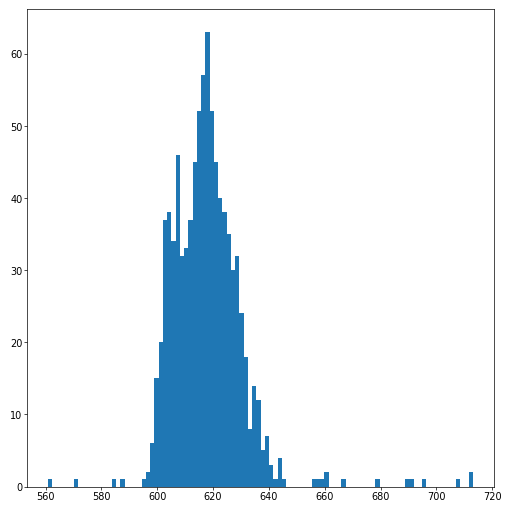

In [20]:
plt.hist(agg_stats['mean_wl'], 100);
plt.show()

In [21]:
def plot_single_aggregate(
    cluster_id,
    df_with_wavelengths,
    fov_image,
    image_total,
    oversampling=8,
    pixel_size_nm=69.0,
    pad_px=4,
    wl_min=None,
    wl_max=None,
    colormap='jet',
    scalebar_nm=200,
    box_color='white',
    box_lw=1.5,
    vmin_pct=1.0,
    vmax_pct=99.9,
    savepath=None,
):
    """
    Plot a single aggregate: full FOV with a bounding box (left panel)
    and a zoomed view cropped from the pre-rendered fov_image (right panel).

    The zoom panel is a direct crop of fov_image — no re-render is performed.
    fov_image must have been rendered at `oversampling` with origin (0, 0).

    Brightness of the cropped zoom is renormalised to [vmin_pct, vmax_pct]
    percentiles of the grayscale image_total crop, with hue/saturation
    preserved via HSV conversion (same approach as SAureus_PostAnalysis).
    """
    import matplotlib.colors as mcolors

    grp = df_with_wavelengths[df_with_wavelengths['cluster_id'] == cluster_id]
    if len(grp) == 0:
        raise ValueError(f'cluster_id {cluster_id} not found.')

    # Spatial bounding box in camera pixels
    x_lo = grp['xc'].min() - pad_px
    x_hi = grp['xc'].max() + pad_px
    y_lo = grp['yc'].min() - pad_px
    y_hi = grp['yc'].max() + pad_px

    # Colour scale
    all_wl = df_with_wavelengths['wl_pixel']
    if wl_min is None:
        wl_min = float(np.percentile(all_wl, 1))
    if wl_max is None:
        wl_max = float(np.percentile(all_wl, 99))

    # ── Crop zoom panel from pre-rendered FOV image ───────────────────────────
    H_fov, W_fov = fov_image.shape[:2]
    sr_x0 = max(0,     int(round(x_lo * oversampling)))
    sr_x1 = min(W_fov, int(round(x_hi * oversampling)))
    sr_y0 = max(0,     int(round(y_lo * oversampling)))
    sr_y1 = min(H_fov, int(round(y_hi * oversampling)))
    img_agg        = fov_image[sr_y0:sr_y1, sr_x0:sr_x1].astype(np.float32)
    img_agg_grey   = image_total[sr_y0:sr_y1, sr_x0:sr_x1].astype(np.float32)

    # ── Percentile brightness normalisation (HSV V-channel replacement) ───────
    vlo = np.percentile(img_agg_grey, vmin_pct)
    vhi = np.percentile(img_agg_grey, vmax_pct)
    new_brightness = np.clip((img_agg_grey - vlo) / max(float(vhi - vlo), 1e-6), 0.0, 1.0)
    # Ensure colour image is in [0, 1] before HSV conversion
    colour_max = img_agg.max()
    if colour_max > 1.0:
        img_agg = img_agg / colour_max
    hsv = mcolors.rgb_to_hsv(img_agg)
    hsv[..., 2] = new_brightness
    img_norm = mcolors.hsv_to_rgb(hsv)

    # Bounding box in SR pixels for the FOV panel
    box_x = x_lo * oversampling
    box_y = y_lo * oversampling
    box_w = (x_hi - x_lo) * oversampling
    box_h = (y_hi - y_lo) * oversampling

    sr_pixel_nm  = pixel_size_nm / oversampling
    scalebar_px  = scalebar_nm / sr_pixel_nm

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, (ax_fov, ax_agg) = plotter.two_column_plot(
        ncolumns=2, widthratio=[1, 1], height=2, width=4
    )

    # Left: full FOV with bounding box
    ax_fov.imshow(fov_image, origin='lower', interpolation='bessel')
    rect = plt.Rectangle(
        (box_x, box_y), box_w, box_h,
        linewidth=box_lw, edgecolor=box_color, facecolor='none',
    )
    ax_fov.add_patch(rect)
    ax_fov.set_xticks([]); ax_fov.set_yticks([])

    scalebar_px_FOV = 10000 / sr_pixel_nm
    h, w = fov_image.shape[:2]
    sb_x2 = int(w * 0.90)
    sb_x1 = int(sb_x2 - scalebar_px_FOV)
    sb_y  = int(h * 0.09)
    ax_fov.plot([sb_x1, sb_x2], [sb_y, sb_y], color='white', lw=1.5,
                solid_capstyle='butt')
    ax_fov.text((sb_x1 + sb_x2) / 2, sb_y + h * 0.04,
                '10 µm', color='white', fontsize=6,
                ha='center', va='bottom')

    # Right: zoomed aggregate (brightness-normalised crop)
    ax_agg.imshow(img_norm, origin='lower', interpolation='none')
    ax_agg.set_xticks([]); ax_agg.set_yticks([])

    h, w = img_norm.shape[:2]
    sb_x2 = int(w * 0.90)
    sb_x1 = int(sb_x2 - scalebar_px)
    sb_y  = int(h * 0.09)
    ax_agg.plot([sb_x1, sb_x2], [sb_y, sb_y], color='white', lw=1.5,
                solid_capstyle='butt')
    ax_agg.text((sb_x1 + sb_x2) / 2, sb_y + h * 0.04,
                f'{scalebar_nm} nm', color='white', fontsize=6,
                ha='center', va='bottom')

    # Shared colourbar
    cmap = plt.get_cmap(colormap)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=wl_min, vmax=wl_max))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax_fov, ax_agg], fraction=0.018, pad=0.01, aspect=30)
    cbar.set_label('mean wavelength / nm', fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f'Saved → {savepath}')

    return fig


In [25]:
np.unique(agg_stats['cluster_id'])

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [30]:
oversampling=8
min_blur_width = 4*0.069
n_locs, image_FOV, image_FOV_colour = render.render(
    locs=df_with_wavelengths.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (np.max(df_with_wavelengths['yc']), np.max(df_with_wavelengths['xc']))),
    blur_method="gaussian_colour",
    cparam='wl_pixel',
    c_min=600,
    c_max=645,
    maxdensperc=99.5,
    mindensperc=1,
    min_blur_width=min_blur_width
)

Saved → /scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Aggregate_30.svg


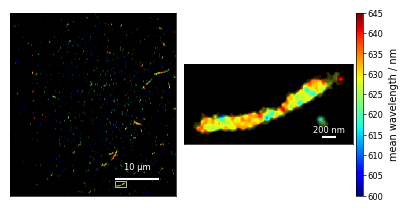

Saved → /scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Aggregate_144.svg


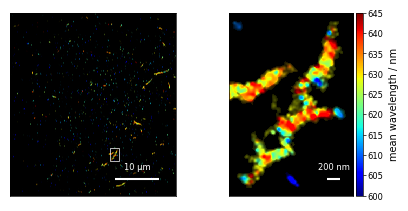

In [ ]:
# Pick a cluster_id from the agg_stats table above, then run this cell.
IDs = [30, 144, 152, 165, 546, 547, 683, 794]
for CLUSTER_ID in IDs:
    #CLUSTER_ID = agg_stats.sort_values('eccentricity', ascending=False)['cluster_id'].iloc[i]
    folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
    
    fig = plot_single_aggregate(
        cluster_id=CLUSTER_ID,
        df_with_wavelengths=df_with_wavelengths,
        fov_image=image_FOV_colour,
        image_total=image_FOV,
        oversampling=8,
        pixel_size_nm=69.0,
        pad_px=2,
        wl_min=600,
        wl_max=645,
        colormap='jet',
        scalebar_nm=200,
        box_color='white',
        box_lw=0.5,
        savepath=os.path.join(folder, f'Aggregate_{CLUSTER_ID}.svg')
    )
    plt.show()


In [ ]:
import seaborn as sns
from matplotlib.colors import LogNorm

agg_stats['log_area'] = np.log10(agg_stats['area_nm2'])
agg_stats['log_area_hull'] = np.log10(agg_stats['area_hull_nm2'])

fig, axs = plotter.one_column_plot(width=1.6, height=2, npanels=2, ratios=[1,1])

sns.kdeplot(data=agg_stats, x="mean_wl", y="n_locs", ax=axs[0], fill=True, log_scale=[False, True], bw_adjust=0.5, levels=50)
axs[1].grid(True, lw=0.5, alpha=0.5, ls='--', color='grey')
axs[0].grid(True, lw=0.5, alpha=0.5, ls='--', color='grey')

sns.kdeplot(data=agg_stats, x="mean_wl", y="minor_axis_nm", ax=axs[1], fill=True, bw_adjust=0.5, levels=50)
#for i in np.arange(2):
#    axs[i].set_xlim([0, 40])

axs[1].set_ylim([0, 200])
#axs[0].set_ylim([5e3, 2e6])

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "AlphaSyn_Analysis_AggregatevsParameters.svg"), dpi=600, format="svg")
plt.show()

In [ ]:
from src.FRCFunctions import fire

In [ ]:
# --- parameters ---
pixel_size_nm = 69      # nm per camera pixel
zoom          = 8      # SR pixels per camera pixel → 6.9 nm SR pixels

# linked_fremoved, width, height already defined in the notebook

# Shift localisations to start from (0,0) within their bounding box                                                                                                                                                                                            
red_xy = df_with_wavelengths[['xc', 'yc']].to_numpy()                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                             
x_min, y_min = red_xy[:, 0].min(), red_xy[:, 1].min()     
red_xy_shifted = red_xy.copy()                                                                                                                                                                                                                                 
red_xy_shifted[:, 0] -= x_min                                                                                                                                                                                                                                  
red_xy_shifted[:, 1] -= y_min
                                                                                                                                                                                                                                                             
nx_eff_red = int(red_xy[:, 0].max() - x_min) + 1                                                                                                                                                                                                                   
ny_eff_red = int(red_xy[:, 1].max() - y_min) + 1                                                                                                                                                                                                                   
print(f"Effective field: {nx_eff_red} × {ny_eff_red} px  ({nx_eff_red*69:.0f} × {ny_eff_red*69:.0f} nm)")                                                                                                                                                                      
                                                                                                                                                                                                                                                             
resolution_nm_655, frc_mean_655, res_hi_nm_655, res_lo_nm_655 = fire(                                                                                                                                                                                          
  positions     = red_xy_shifted,                                                                                                                                                                                                                            
  nx            = nx_eff_red,                                                                                                                                                                                                                                    
  ny            = ny_eff_red,                                                                                                                                                                                                                                    
  zoom          = zoom,
  n_blocks      = 50,                                                                                                                                                                                                                                        
  pixel_size_nm = pixel_size_nm,                                                                                                                                                                                                                             
)                                                                                                                                                                                                                                                              
print(f"FIRE resolution: {resolution_nm_655:.1f} nm")                                                                                                                                                                                                          

In [ ]:
fig, ax = plotter.two_column_plot()

sz_red       = max(nx_eff_red, ny_eff_red) * zoom

sr_px_nm = pixel_size_nm / zoom        # nm per SR pixel

k_red   = np.arange(len(frc_mean_655))
q_red   = k_red / sz_red                           # cycles per SR pixel
q_nm_red = q_red / sr_px_nm                   # cycles per nm  (= 1 / d_nm)

# keep only below Nyquist
mask_red = (q_red > 0) & (q_red < 0.6)

# 1/7 crossing in cycles/nm
q_cross_655 = 1.0 / resolution_nm_655         # cycles per nm at the FIRE value
q_hi_655    = 1.0 / res_hi_nm_655
q_lo_655    = 1.0 / res_lo_nm_655

ax = plotter.line_plot(ax, q_nm_red[mask_red], frc_mean_655[mask_red], label='FRC (mean), Nile Red', color='darkred')

ax.axhline(1/7, color='gray', ls='--', lw=1, label='1/7 threshold')
ax.axvline(q_cross_655, color='crimson', ls='-', lw=1,
           label=f'FIRE = {resolution_nm_655:.0f} nm')
ax.axvspan(q_lo_655, q_hi_655, alpha=0.15, color='crimson', label='±1σ')

ax.set_xlabel(r'1 / spatial frequency (nm)', fontsize=8)
ax.set_ylabel('FRC', fontsize=8)
ax.set_ylim([0, 1.05])
ax.set_xscale('log')

tick_nm = [2000, 500, 200, 100, 50, 30, 20]          # nm values to label
ax.set_xticks([1/d for d in tick_nm])

ax.set_xticklabels([f'{d} nm' for d in tick_nm])
ax.set_xlim(1/2000, 1/15)
ax.legend(fontsize=7)

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "FRC_ASyn.svg"), dpi=600, format="svg")
